In [1]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task
import statsmodels.api as sm

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [23]:


# 读取 MCMC 采样数据
trace = az.from_netcdf("low_branch_trace_noIP_config4.nc")

# 查看 trace 中的变量
print(trace.posterior)


<xarray.Dataset> Size: 9MB
Dimensions:           (chain: 4, draw: 3000, S_dim_0: 7, beta_m_dim_0: 30,
                       gamma_prev_dim_0: 7, gamma_dim_0: 7, p_dim_0: 30,
                       beta_dim_0: 7)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 24kB 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
  * S_dim_0           (S_dim_0) int64 56B 0 1 2 3 4 5 6
  * beta_m_dim_0      (beta_m_dim_0) int64 240B 0 1 2 3 4 5 ... 25 26 27 28 29
  * gamma_prev_dim_0  (gamma_prev_dim_0) int64 56B 0 1 2 3 4 5 6
  * gamma_dim_0       (gamma_dim_0) int64 56B 0 1 2 3 4 5 6
  * p_dim_0           (p_dim_0) int64 240B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29
  * beta_dim_0        (beta_dim_0) int64 56B 0 1 2 3 4 5 6
Data variables:
    S                 (chain, draw, S_dim_0) int64 672kB ...
    beta_ori          (chain, draw) float64 96kB ...
    beta_m            (chain, draw, beta_m_dim_0) float64 3MB ...
    gamma_prev        (chain, draw, gamma_prev_dim_

In [62]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))




# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})


# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)

import statsmodels.api as sm
print(df.columns.tolist())

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','AMIN','BT','IP','RGEO','PLTH','NEL','PGASA','KAPPA','Q95','AUXHEAT',"DIVCON"]
new_df = df[df['SELEC2024'] == 0][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/2
new_df['a1']=np.pi*new_df['RGEO']*2*mu0
new_df['a']=new_df['AMIN']/new_df['RGEO']
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame



columns_to_include_for_regre = ['BP','IP','BT','a','a1','SPLASMA','AMIN','RGEO','KAPPA','Q95','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()
unique_heating = new_df['AUXHEAT'].unique()
print(unique_heating)
# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BT','IP','SPLASMA','a1','NEL','PGASA']] 
#x = multi_df[['BT','NEL','PGASA']]
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xptin'], axis=1, inplace=True)
#x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5L','HT3','HT3R','HT3L','VT','CORNER','V5',' VERTPLT'], axis=1, inplace=True)

X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())
print(unique_divcon)
# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)


['TOK', 'SHOT', 'TIME', 'PHASE', 'PGASA', 'RGEO', 'AMIN', 'KAPPA', 'SPLASMA', 'CONFIG', 'IGRADB', 'WALMAT', 'DIVMAT', 'LIMMAT', 'EVAP', 'BT', 'IP', 'Q95', 'NEL', 'ZEFF', 'DIVNAME', 'PL', 'PLTH', 'PFLOSS', 'PRADCORE', 'DIVCON', 'FRACNMIN', 'LHTIME', 'AUXHEAT', 'SELEC2024', 'Category']
['IC' 'EC' 'NBEC' 'ECIC' 'NB' 'NBIC' nan]
                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     212.7
Date:                Wed, 07 May 2025   Prob (F-statistic):           5.87e-84
Time:                        16:53:00   Log-Likelihood:                 11.090
No. Observations:                 207   AIC:                            -8.180
Df Residuals:                     200   BIC:                             15.15
Df Model:                           6    

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/2333260952.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/2333260952.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/2333260952.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 412 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 3414 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


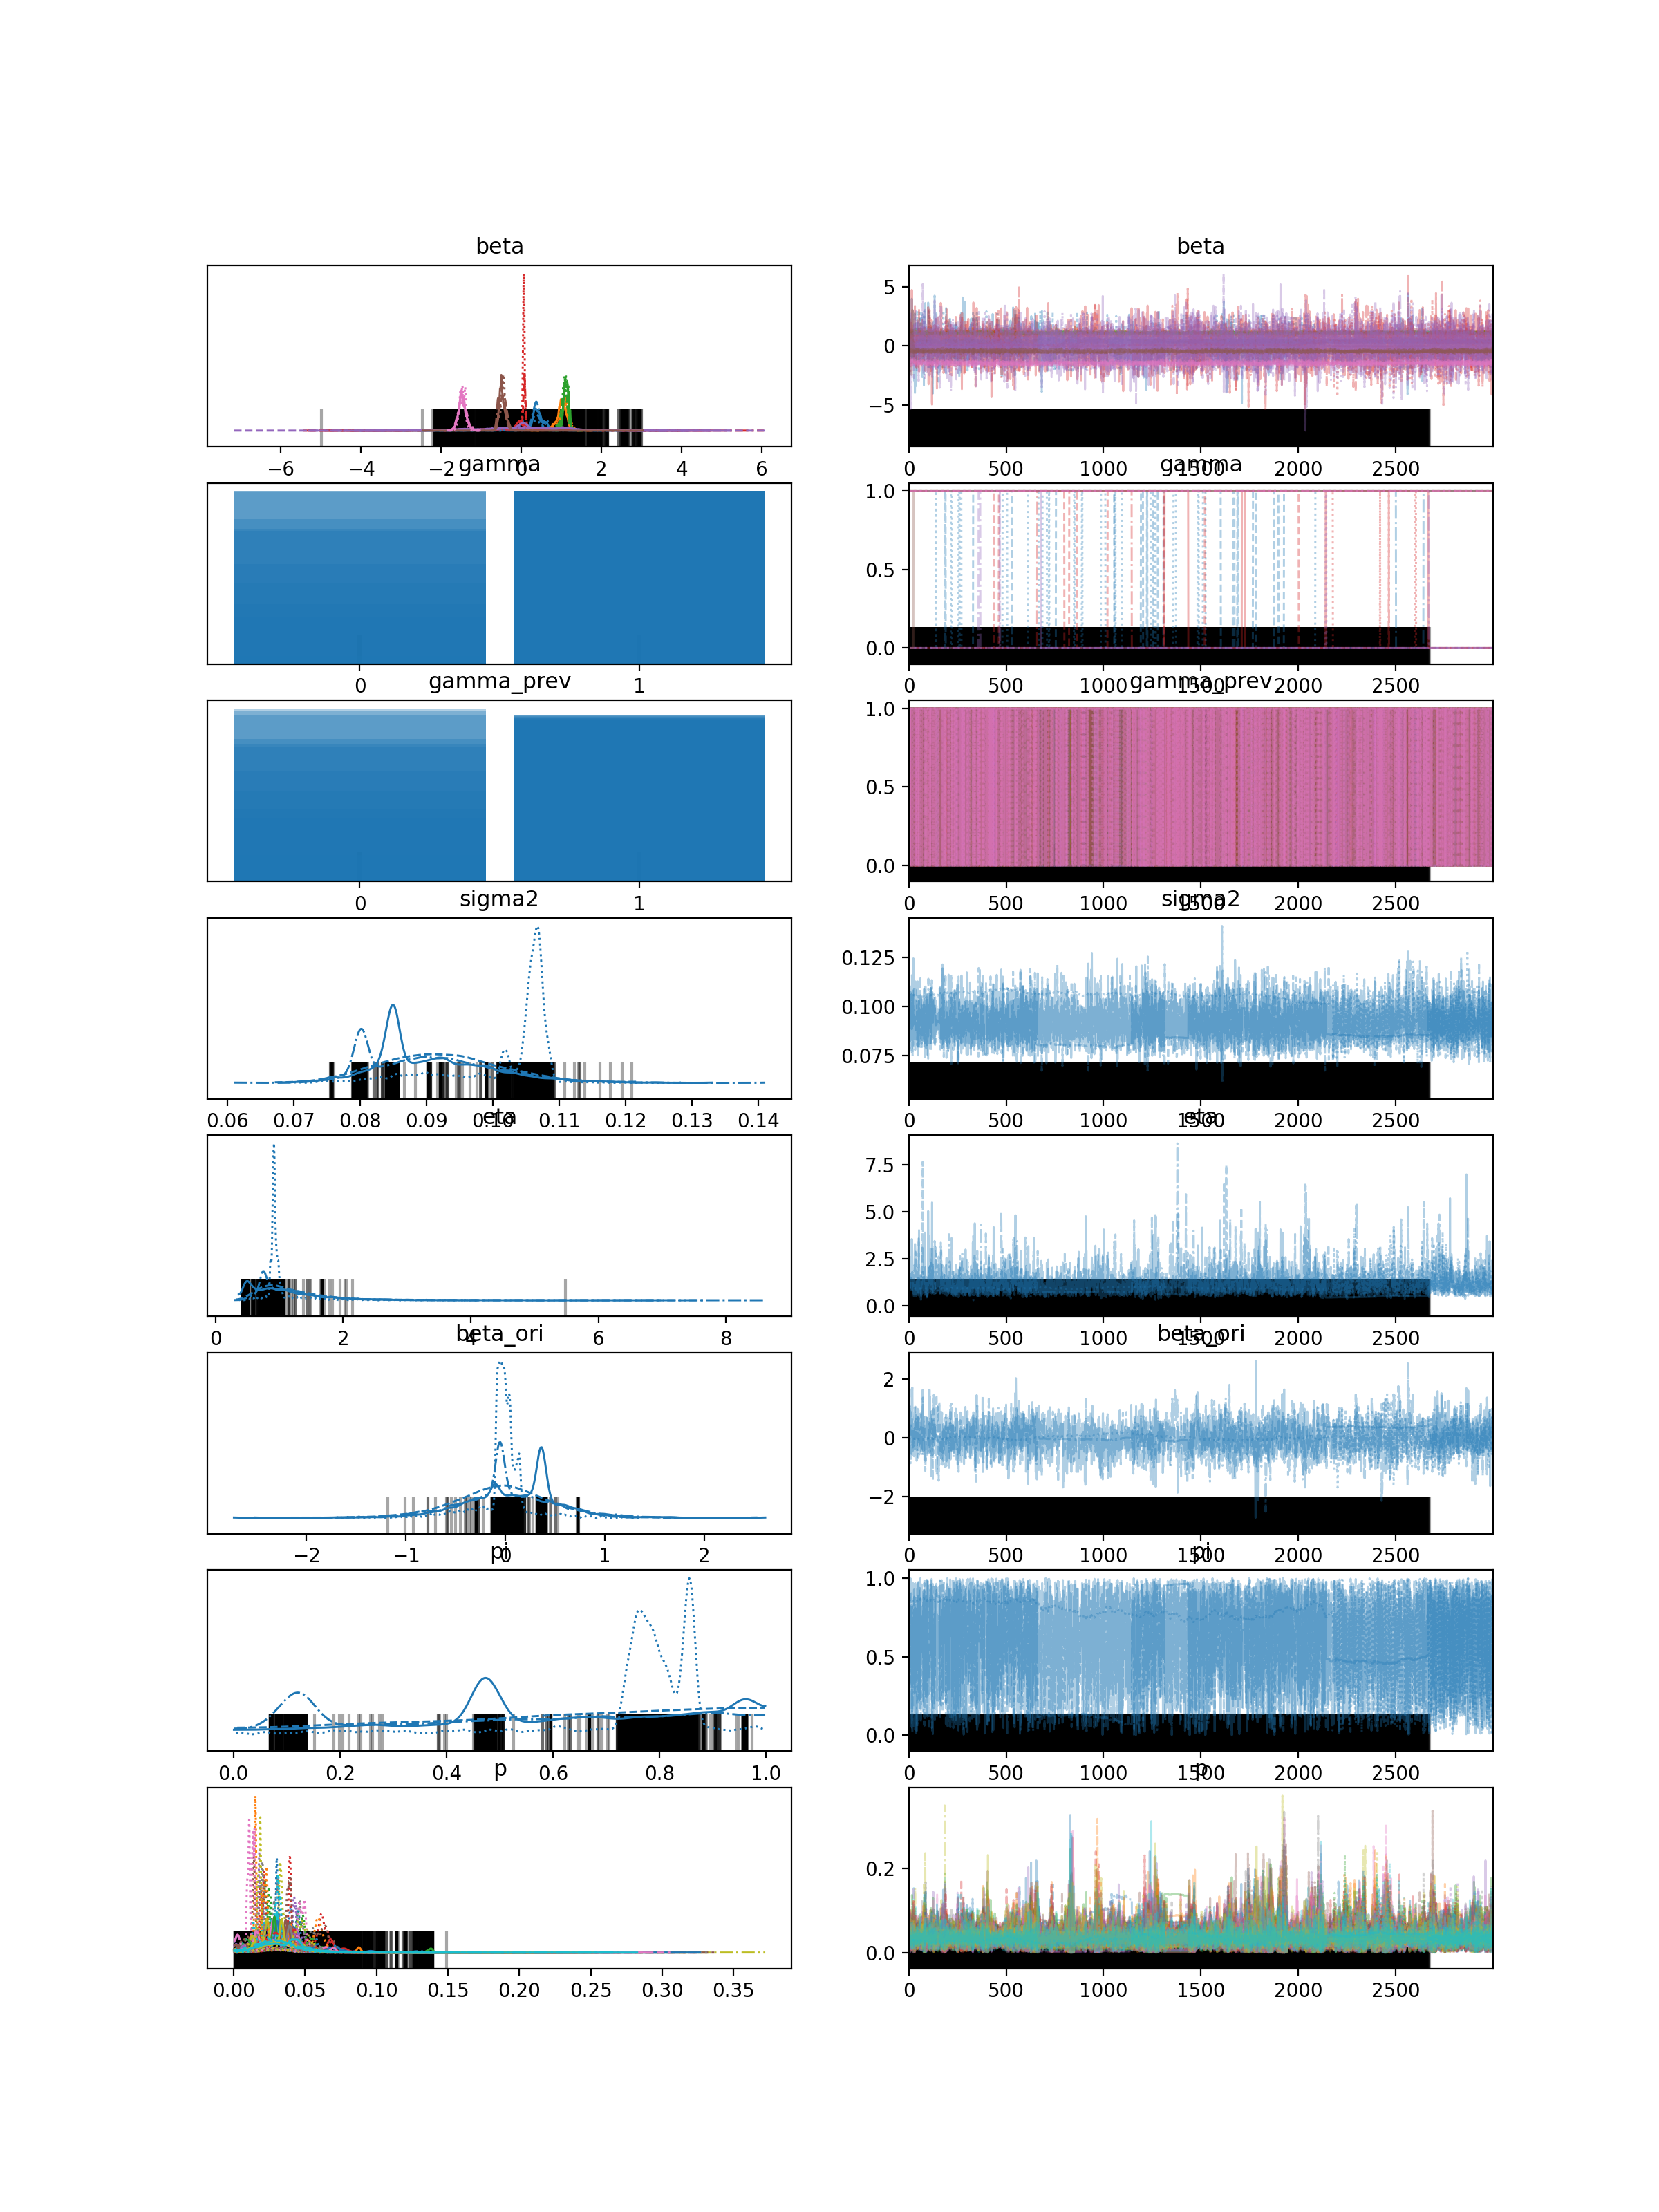

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        0.317  0.610  -1.090    1.468      0.055    0.039      73.0   
beta[1]        1.033  0.141   0.757    1.298      0.021    0.015      40.0   
beta[2]        1.093  0.074   0.958    1.226      0.015    0.011      24.0   
beta[3]        0.027  0.923  -1.763    1.991      0.011    0.070    1970.0   
beta[4]        0.046  1.091  -2.142    1.869      0.020    0.023    2615.0   
beta[5]       -0.467  0.106  -0.614   -0.323      0.009    0.007      73.0   
beta[6]       -1.470  0.095  -1.651   -1.288      0.004    0.003     652.0   
gamma[0]       0.756  0.429   0.000    1.000      0.131    0.095      11.0   
gamma[1]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[2]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[3]       0.410  0.492   0.000    1.000      0.149    0.108      11.0   
gamma[4]       0.058  0.234   0.000    0.000      0.073    0.053

In [63]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 7  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=2)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


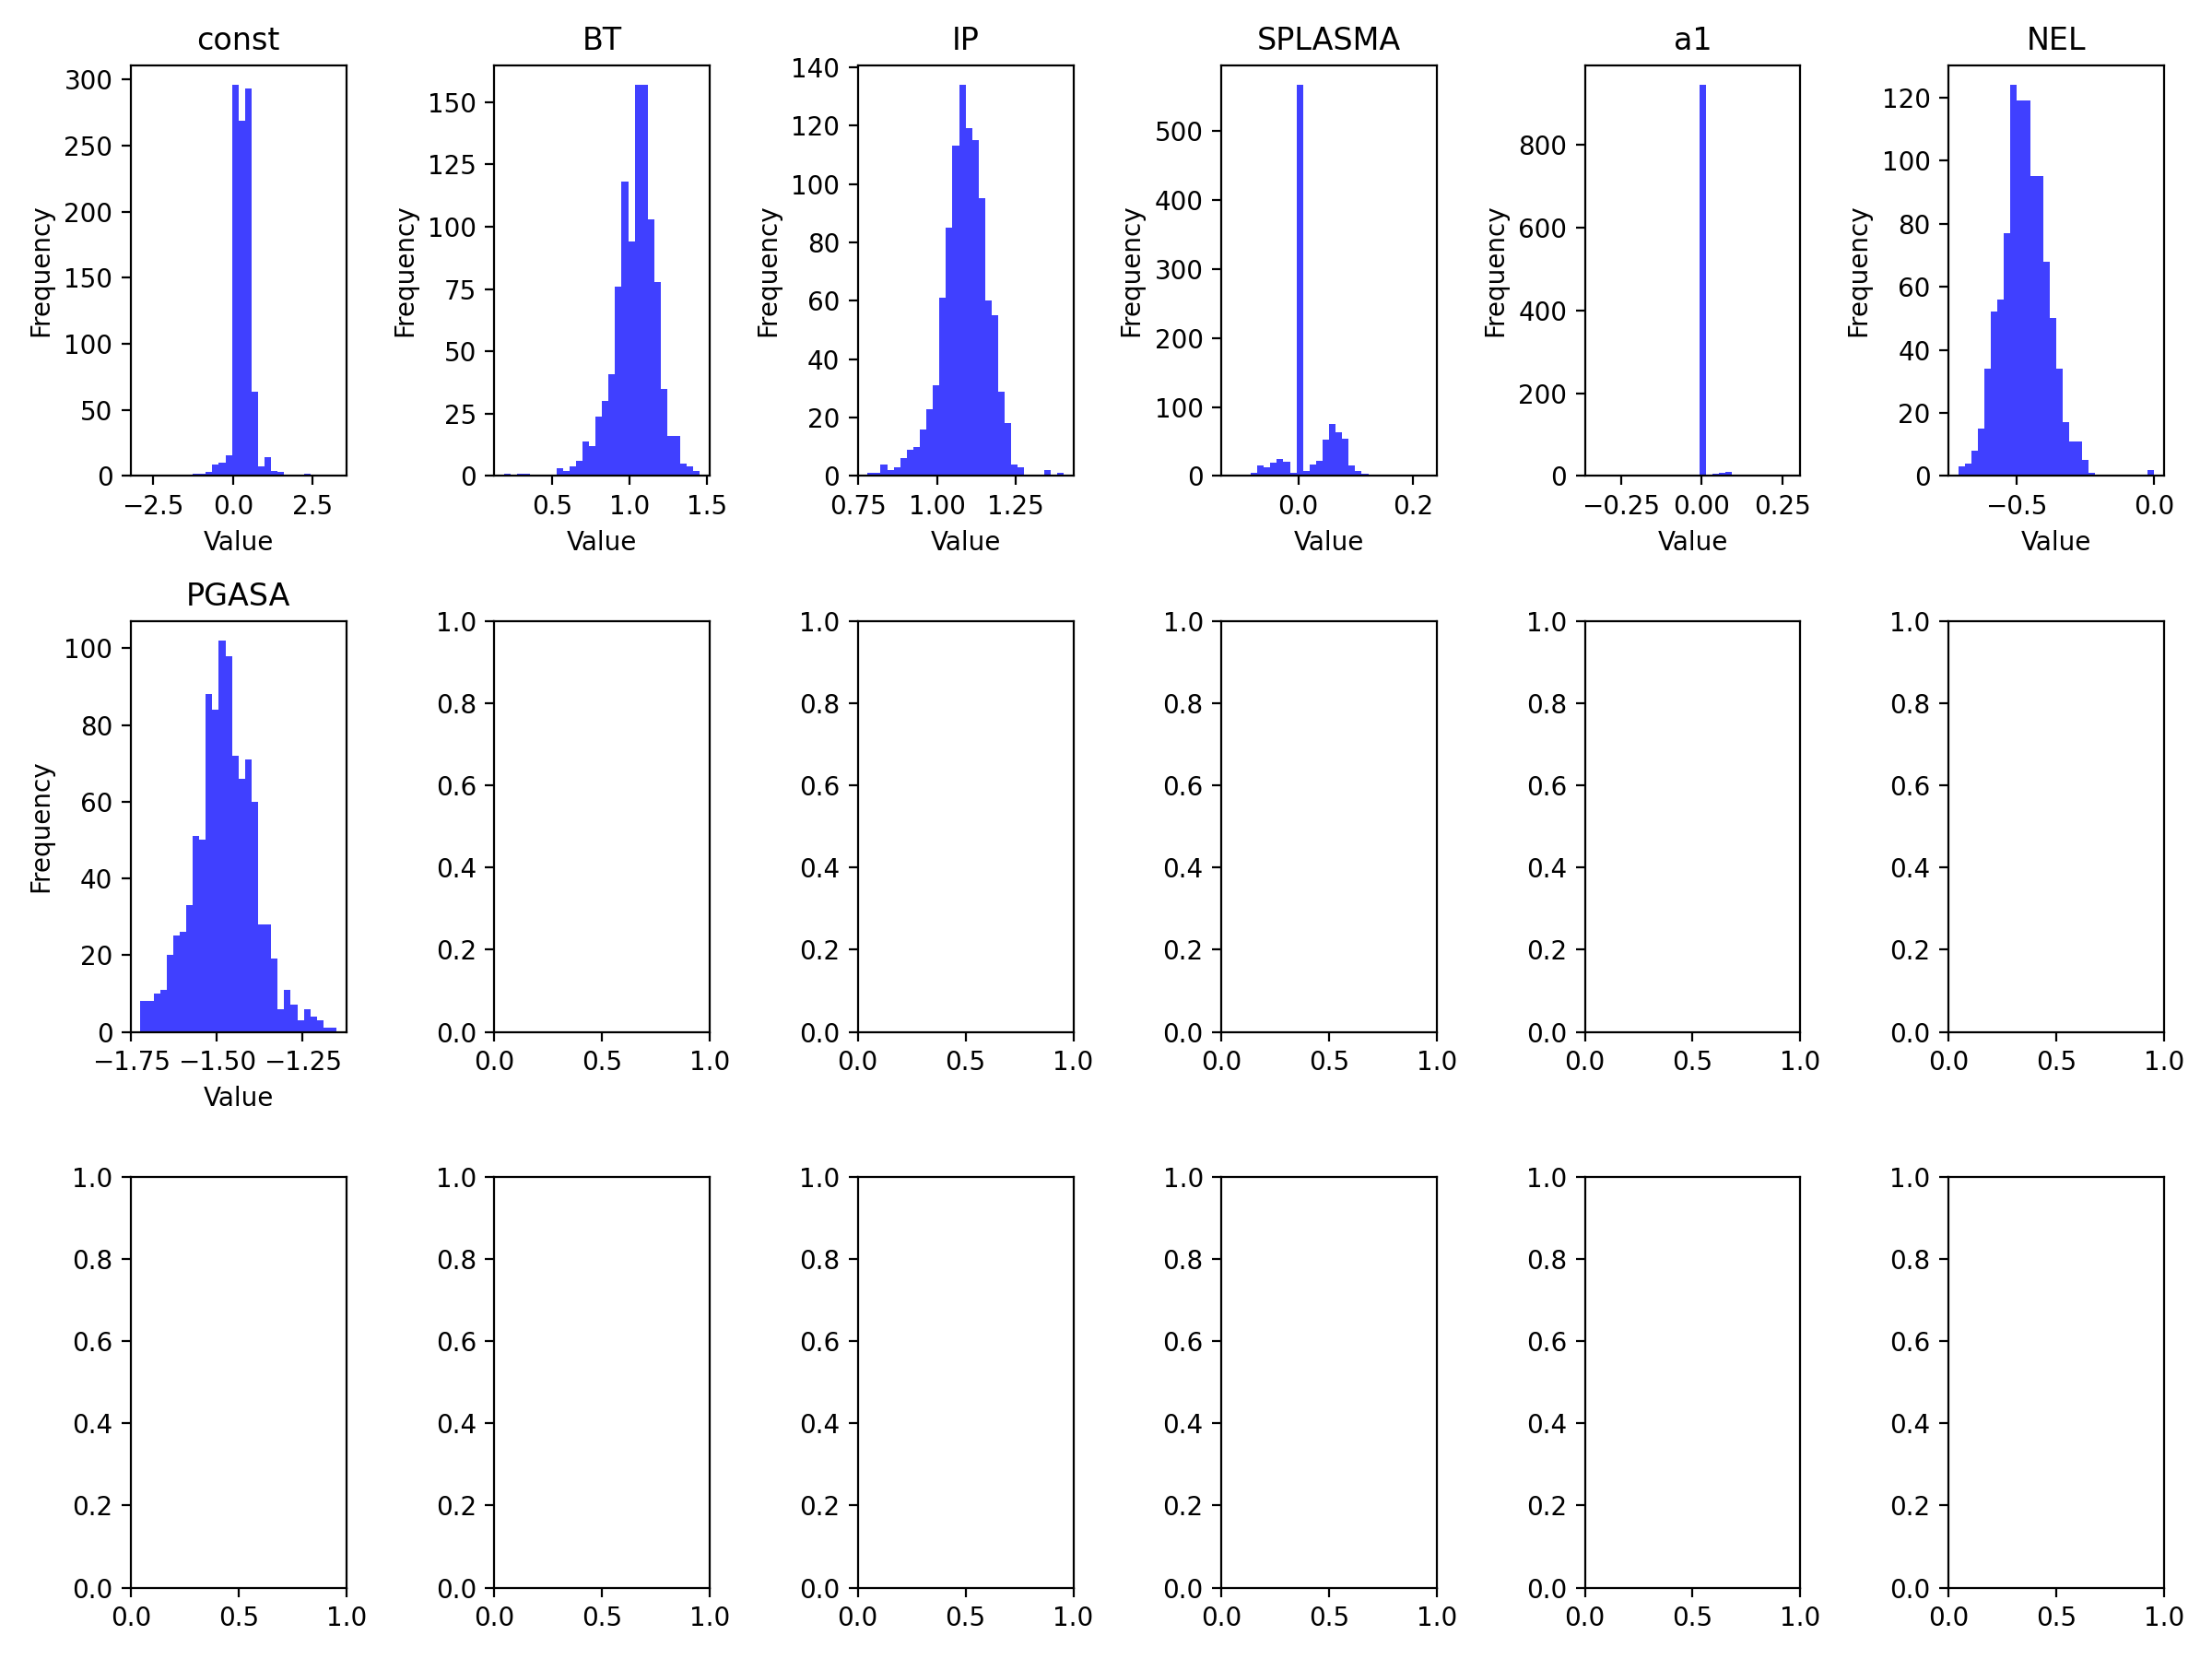

[0.753 1.    1.    0.436 0.062 0.998 1.   ]
[ 2.79909450e-01  1.03748019e+00  1.08988712e+00  1.79061063e-02
  8.71074922e-04 -4.69526716e-01 -1.47716127e+00]
[13.849 11.777 14.183 14.548 15.561 13.4   14.583]
1000 samples' R² values=: 0.8601


In [64]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(12, 9))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

<IPython.core.display.Javascript object>


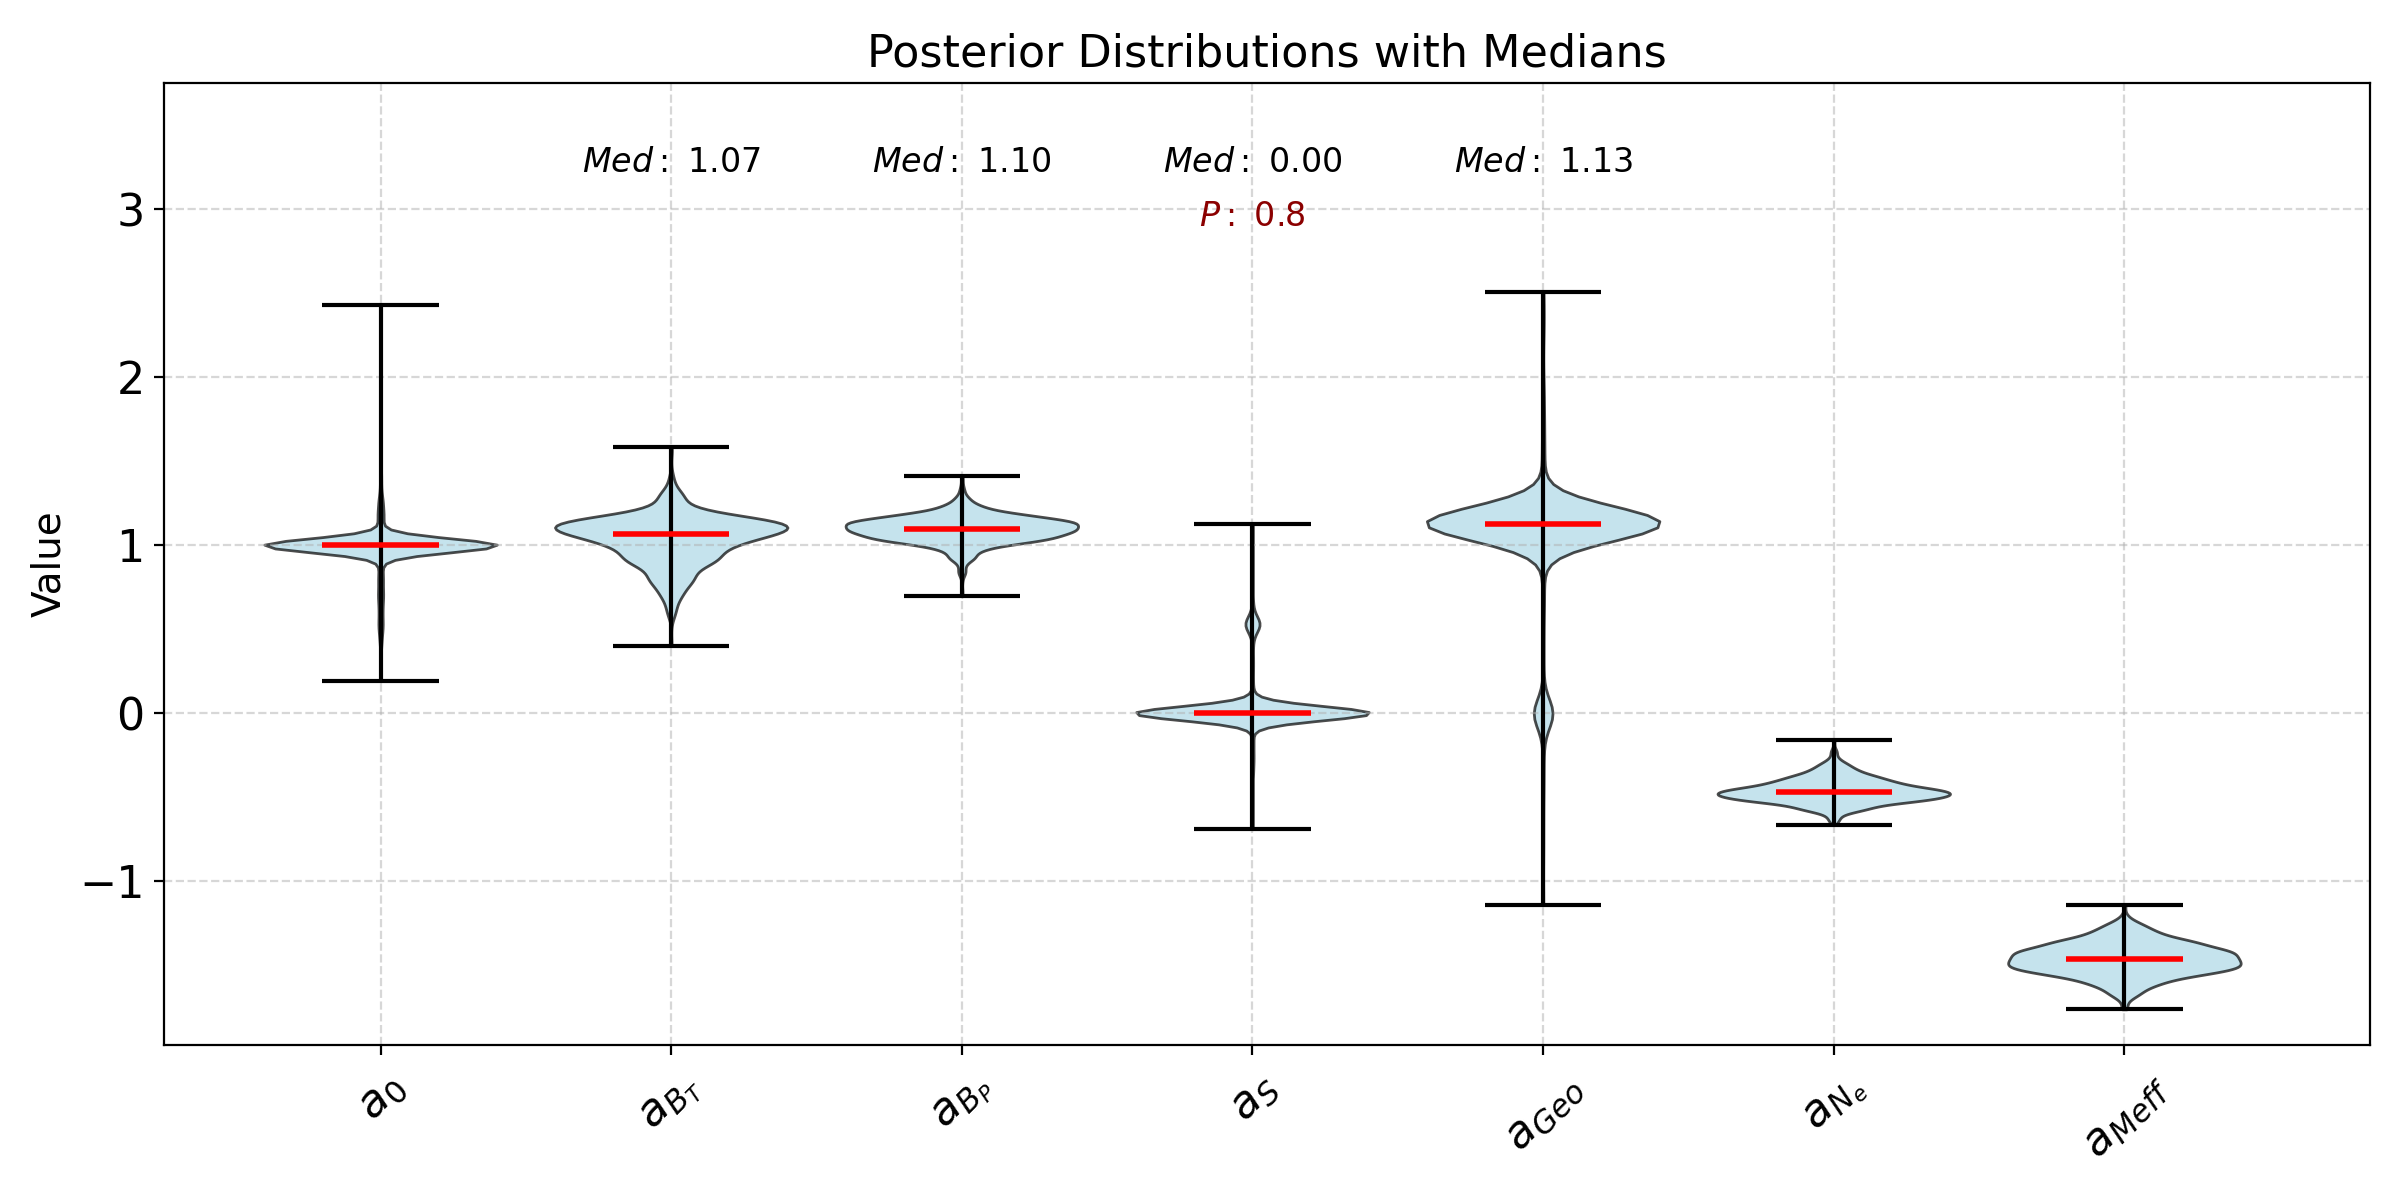


Gamma means: [0.169 1.    1.    0.17  0.942 1.    1.   ]
S means: [-0.01635935  1.03684405  1.0959186   0.03781571  1.05508283 -0.46091024
 -1.46186724]
Beta new look means: [13.946 15.643 14.936 14.25  14.797 13.34  13.826]

Predictions shape: (207,)
1000 samples' RMSE: 0.2327


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{B_T}$","$a_{B_P}$","$a_{S}$","$a_{Geo}$","$a_{N_e}$","$a_{Meff}$"]

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 7  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 :  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)


# 创建图形
plt.figure(figsize=(12,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 7  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if i > 0 and gamma_prob_0[i] > 0.5:  # 跳过第一个变量
        prob_text = f"$P:$ {gamma_prob_0[i]:.1f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')

# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[1:5], medians[1:5]):
    plt.text(pos, y_top * 1.17, f"$Med:$ {median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
plt.savefig('part_toshow_low_new_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")

In [37]:


# 读取 MCMC 采样数据
trace = az.from_netcdf("low_branch_trace_different_config.nc")

# 查看 trace 中的变量
print(trace.posterior)


<xarray.Dataset> Size: 18MB
Dimensions:           (chain: 4, draw: 3000, S_dim_0: 15, beta_m_dim_0: 60,
                       gamma_prev_dim_0: 15, gamma_dim_0: 15, p_dim_0: 60,
                       beta_dim_0: 15)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 24kB 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
  * S_dim_0           (S_dim_0) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * beta_m_dim_0      (beta_m_dim_0) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
  * gamma_prev_dim_0  (gamma_prev_dim_0) int64 120B 0 1 2 3 4 ... 10 11 12 13 14
  * gamma_dim_0       (gamma_dim_0) int64 120B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * p_dim_0           (p_dim_0) int64 480B 0 1 2 3 4 5 6 ... 54 55 56 57 58 59
  * beta_dim_0        (beta_dim_0) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
Data variables:
    S                 (chain, draw, S_dim_0) int64 1MB ...
    beta_ori          (chain, draw) float64 96kB ...
    beta_m            (chain, draw

In [38]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))




# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})


# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)

import statsmodels.api as sm
print(df.columns.tolist())

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','AMIN','BT','IP','RGEO','PLTH','NEL','PGASA','KAPPA','Q95','AUXHEAT',"DIVCON"]
new_df = df[df['SELEC2024'] == 0][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/2
new_df['a1']=new_df['SPLASMA']/(np.pi*new_df['RGEO']*2)
new_df['a']=new_df['AMIN']/new_df['RGEO']
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame



columns_to_include_for_regre = ['BP','IP','BT','a','AMIN','RGEO','KAPPA','Q95','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()
unique_heating = new_df['AUXHEAT'].unique()
print(unique_heating)
# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BT','IP','NEL','PGASA']] 
#x = multi_df[['BT','NEL','PGASA']]
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
#x.drop(['Xptref','Xptin'], axis=1, inplace=True)
#x['CV'] = x[['CORNER','VT']].max(axis=1)
#x.drop(['V5L','HT3'], axis=1, inplace=True)

X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())
print(unique_divcon)
# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)


['TOK', 'SHOT', 'TIME', 'PHASE', 'PGASA', 'RGEO', 'AMIN', 'KAPPA', 'SPLASMA', 'CONFIG', 'IGRADB', 'WALMAT', 'DIVMAT', 'LIMMAT', 'EVAP', 'BT', 'IP', 'Q95', 'NEL', 'ZEFF', 'DIVNAME', 'PL', 'PLTH', 'PFLOSS', 'PRADCORE', 'DIVCON', 'FRACNMIN', 'LHTIME', 'AUXHEAT', 'SELEC2024', 'Category']
['IC' 'EC' 'NBEC' 'ECIC' 'NB' 'NBIC' nan]
                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     108.6
Date:                Tue, 06 May 2025   Prob (F-statistic):           3.83e-83
Time:                        17:55:57   Log-Likelihood:                 30.686
No. Observations:                 207   AIC:                            -31.37
Df Residuals:                     192   BIC:                             18.62
Df Model:                          14    

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/320255815.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/320255815.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/320255815.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


<IPython.core.display.Javascript object>


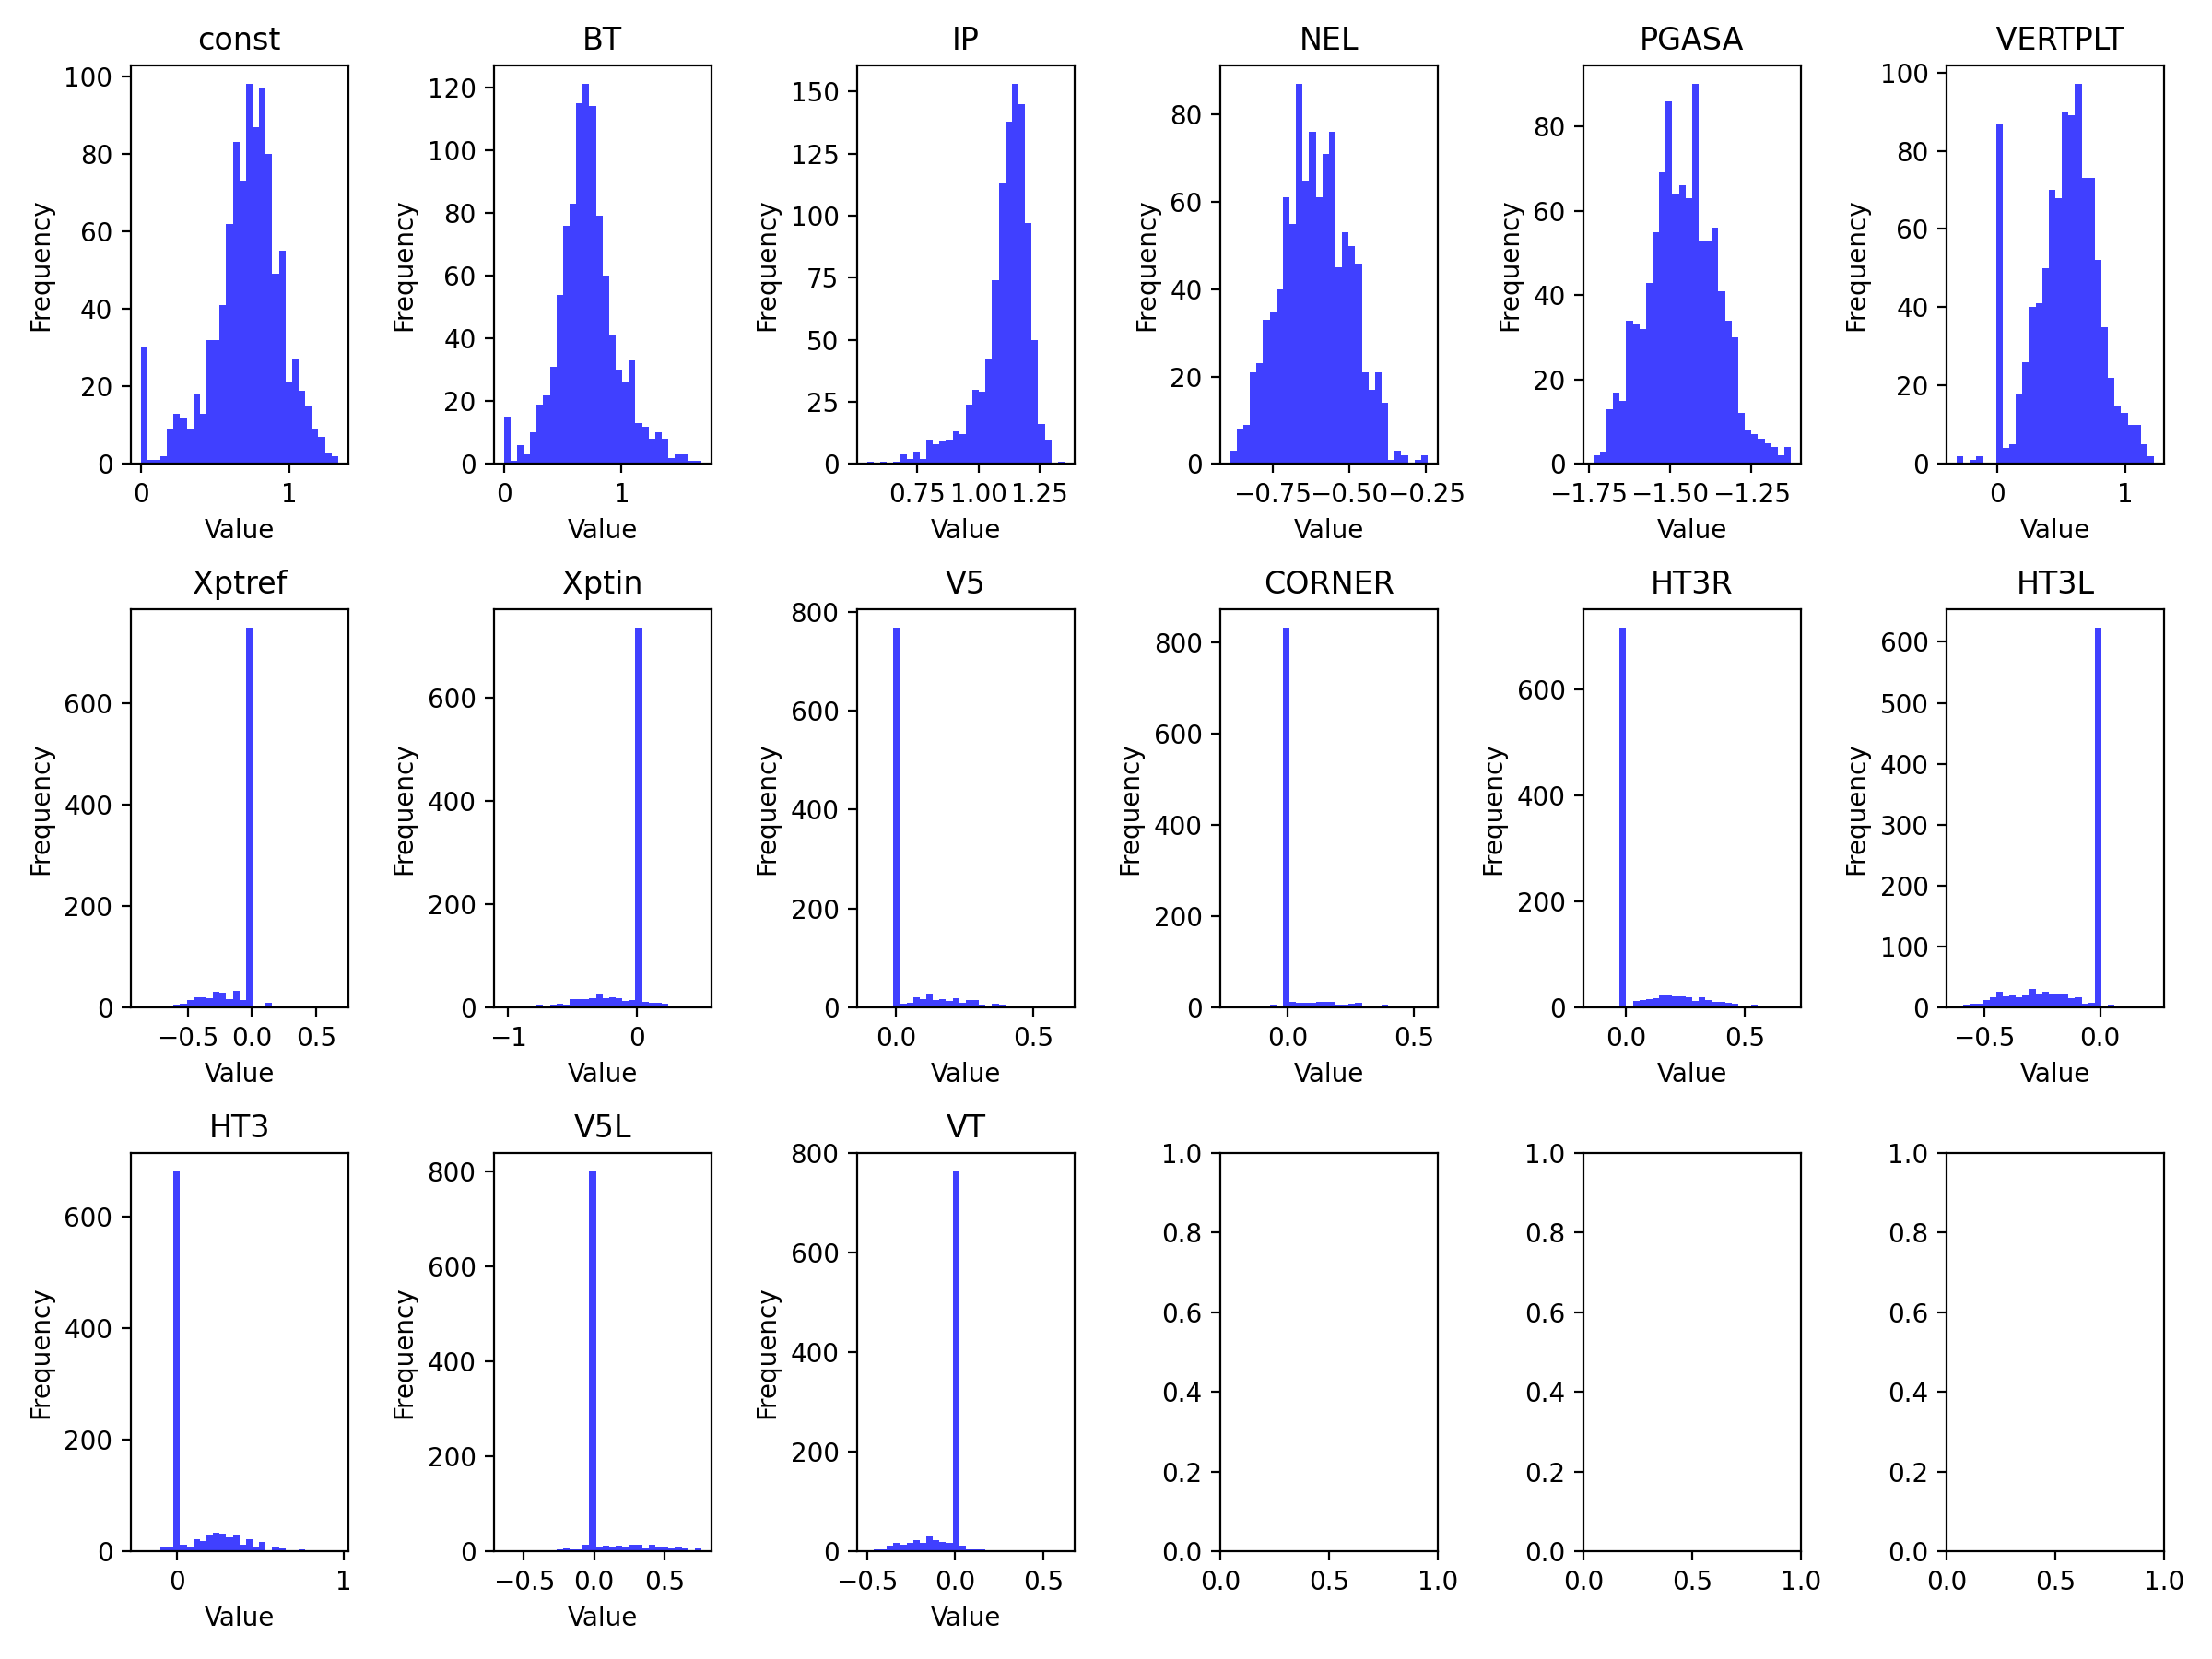

[0.97  0.986 1.    1.    1.    0.916 0.266 0.273 0.237 0.182 0.293 0.387
 0.329 0.212 0.254]
[ 0.7132533   0.71510645  1.10881955 -0.61054523 -1.46073019  0.52520605
 -0.06132265 -0.06174347  0.04207297  0.02422062  0.06734459 -0.10263311
  0.09240662  0.04290539 -0.03586109]
[27.651 29.431 30.43  32.882 31.094 28.218 30.418 30.098 30.143 29.609
 28.573 30.684 29.09  30.163 28.156]
1000 samples' R² values=: 0.8789


In [39]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(12, 9))
axes = axes.flatten()

for i in range(15):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
#plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

<IPython.core.display.Javascript object>


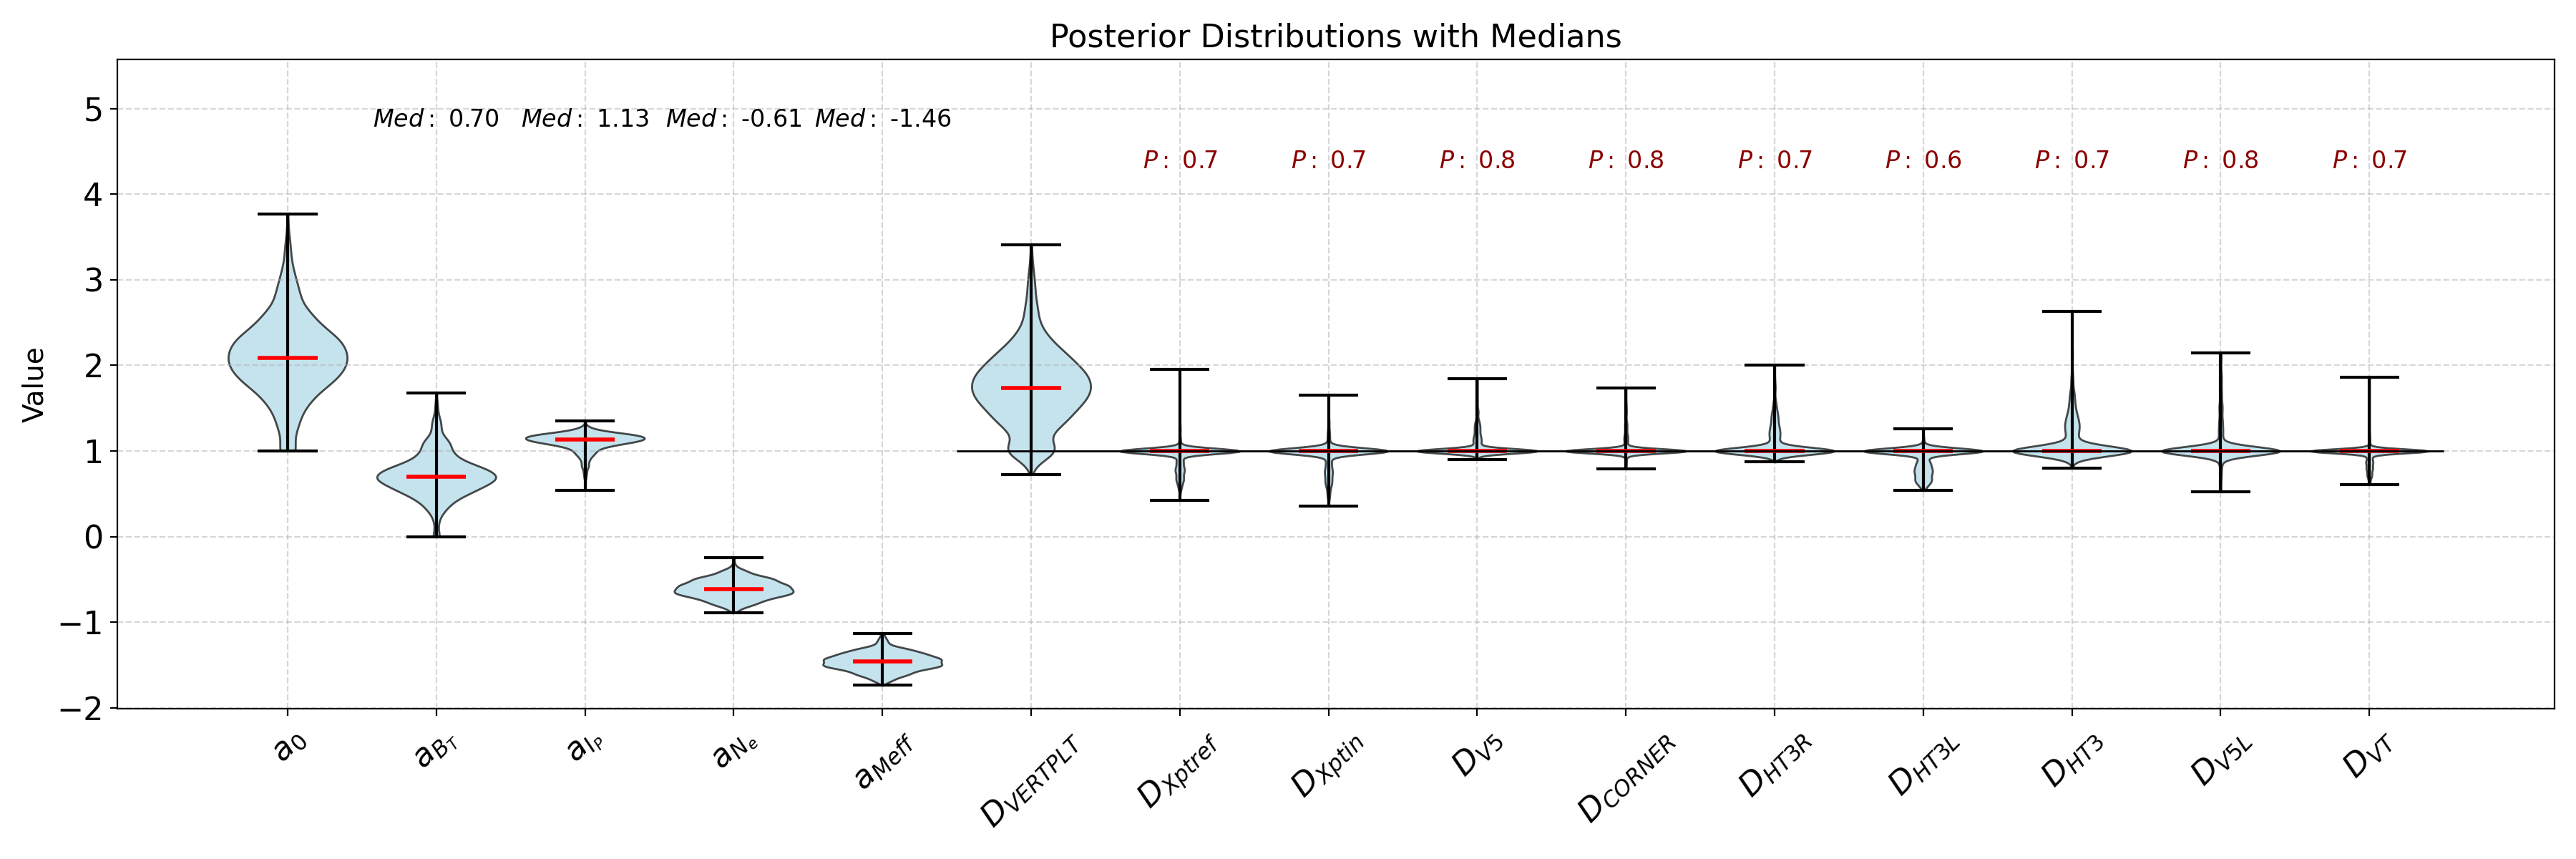


Gamma means: [0.97  0.986 1.    1.    1.    0.916 0.266 0.273 0.237 0.182 0.293 0.387
 0.329 0.212 0.254]
S means: [ 0.7132533   0.71510645  1.10881955 -0.61054523 -1.46073019  0.52520605
 -0.06132265 -0.06174347  0.04207297  0.02422062  0.06734459 -0.10263311
  0.09240662  0.04290539 -0.03586109]
Beta new look means: [27.651 29.431 30.43  32.882 31.094 28.218 30.418 30.098 30.143 29.609
 28.573 30.684 29.09  30.163 28.156]

Predictions shape: (207,)
1000 samples' RMSE: 0.2169


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$","$a_{B_T}$","$a_{I_P}$","$a_{N_e}$","$a_{Meff}$", "$D_{VERTPLT}$", "$D_{Xptref}$", "$D_{Xptin}$", "$D_{V5}$", 
          "$D_{CORNER}$", "$D_{HT3R}$","$D_{HT3L}$", "$D_{HT3}$", "$D_{V5L}$","$D_{VT}$"]


S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 15  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i in [0,5,6,7,8,9,10,11,12,13,14] :  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)


# 创建图形
plt.figure(figsize=(18,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 5  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if i > 0 and gamma_prob_0[i] > 0.5:  # 跳过第一个变量
        prob_text = f"$P:$ {gamma_prob_0[i]:.1f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')

# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[1:5], medians[1:5]):
    plt.text(pos, y_top * 1.17, f"$Med:$ {median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
plt.savefig('part_toshow2_low_new_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")

In [50]:


# 读取 MCMC 采样数据
trace = az.from_netcdf("low_branch_trace_noIP_config3.nc")

# 查看 trace 中的变量
print(trace.posterior)


<xarray.Dataset> Size: 9MB
Dimensions:           (chain: 4, draw: 3000, S_dim_0: 6, beta_m_dim_0: 30,
                       gamma_prev_dim_0: 6, gamma_dim_0: 6, p_dim_0: 30,
                       beta_dim_0: 6)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 24kB 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
  * S_dim_0           (S_dim_0) int64 48B 0 1 2 3 4 5
  * beta_m_dim_0      (beta_m_dim_0) int64 240B 0 1 2 3 4 5 ... 25 26 27 28 29
  * gamma_prev_dim_0  (gamma_prev_dim_0) int64 48B 0 1 2 3 4 5
  * gamma_dim_0       (gamma_dim_0) int64 48B 0 1 2 3 4 5
  * p_dim_0           (p_dim_0) int64 240B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29
  * beta_dim_0        (beta_dim_0) int64 48B 0 1 2 3 4 5
Data variables:
    S                 (chain, draw, S_dim_0) int64 576kB ...
    beta_ori          (chain, draw) float64 96kB ...
    beta_m            (chain, draw, beta_m_dim_0) float64 3MB ...
    gamma_prev        (chain, draw, gamma_prev_dim_0) int64

In [65]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))




# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})


# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)

import statsmodels.api as sm
print(df.columns.tolist())

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','AMIN','BT','IP','RGEO','PLTH','NEL','PGASA','KAPPA','Q95','AUXHEAT',"DIVCON"]
new_df = df[df['SELEC2024'] == 0][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/2
new_df['a1']=new_df['SPLASMA']/(np.pi*new_df['RGEO']*2)
new_df['a']=new_df['AMIN']/new_df['RGEO']
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame



columns_to_include_for_regre = ['BP','IP','BT','a','AMIN','RGEO','KAPPA','Q95','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()
unique_heating = new_df['AUXHEAT'].unique()
print(unique_heating)
# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BT','IP','NEL','PGASA']] 
#x = multi_df[['BT','NEL','PGASA']]
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xptin'], axis=1, inplace=True)
#x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5L','HT3','HT3R','HT3L','VT','CORNER','V5',' VERTPLT'], axis=1, inplace=True)

X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())
print(unique_divcon)
# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)


['TOK', 'SHOT', 'TIME', 'PHASE', 'PGASA', 'RGEO', 'AMIN', 'KAPPA', 'SPLASMA', 'CONFIG', 'IGRADB', 'WALMAT', 'DIVMAT', 'LIMMAT', 'EVAP', 'BT', 'IP', 'Q95', 'NEL', 'ZEFF', 'DIVNAME', 'PL', 'PLTH', 'PFLOSS', 'PRADCORE', 'DIVCON', 'FRACNMIN', 'LHTIME', 'AUXHEAT', 'SELEC2024', 'Category']
['IC' 'EC' 'NBEC' 'ECIC' 'NB' 'NBIC' nan]
                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     313.0
Date:                Wed, 07 May 2025   Prob (F-statistic):           2.35e-85
Time:                        19:08:33   Log-Likelihood:                 8.4651
No. Observations:                 207   AIC:                            -6.930
Df Residuals:                     202   BIC:                             9.733
Df Model:                           4    

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/3991532573.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/3991532573.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_51536/3991532573.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 328 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


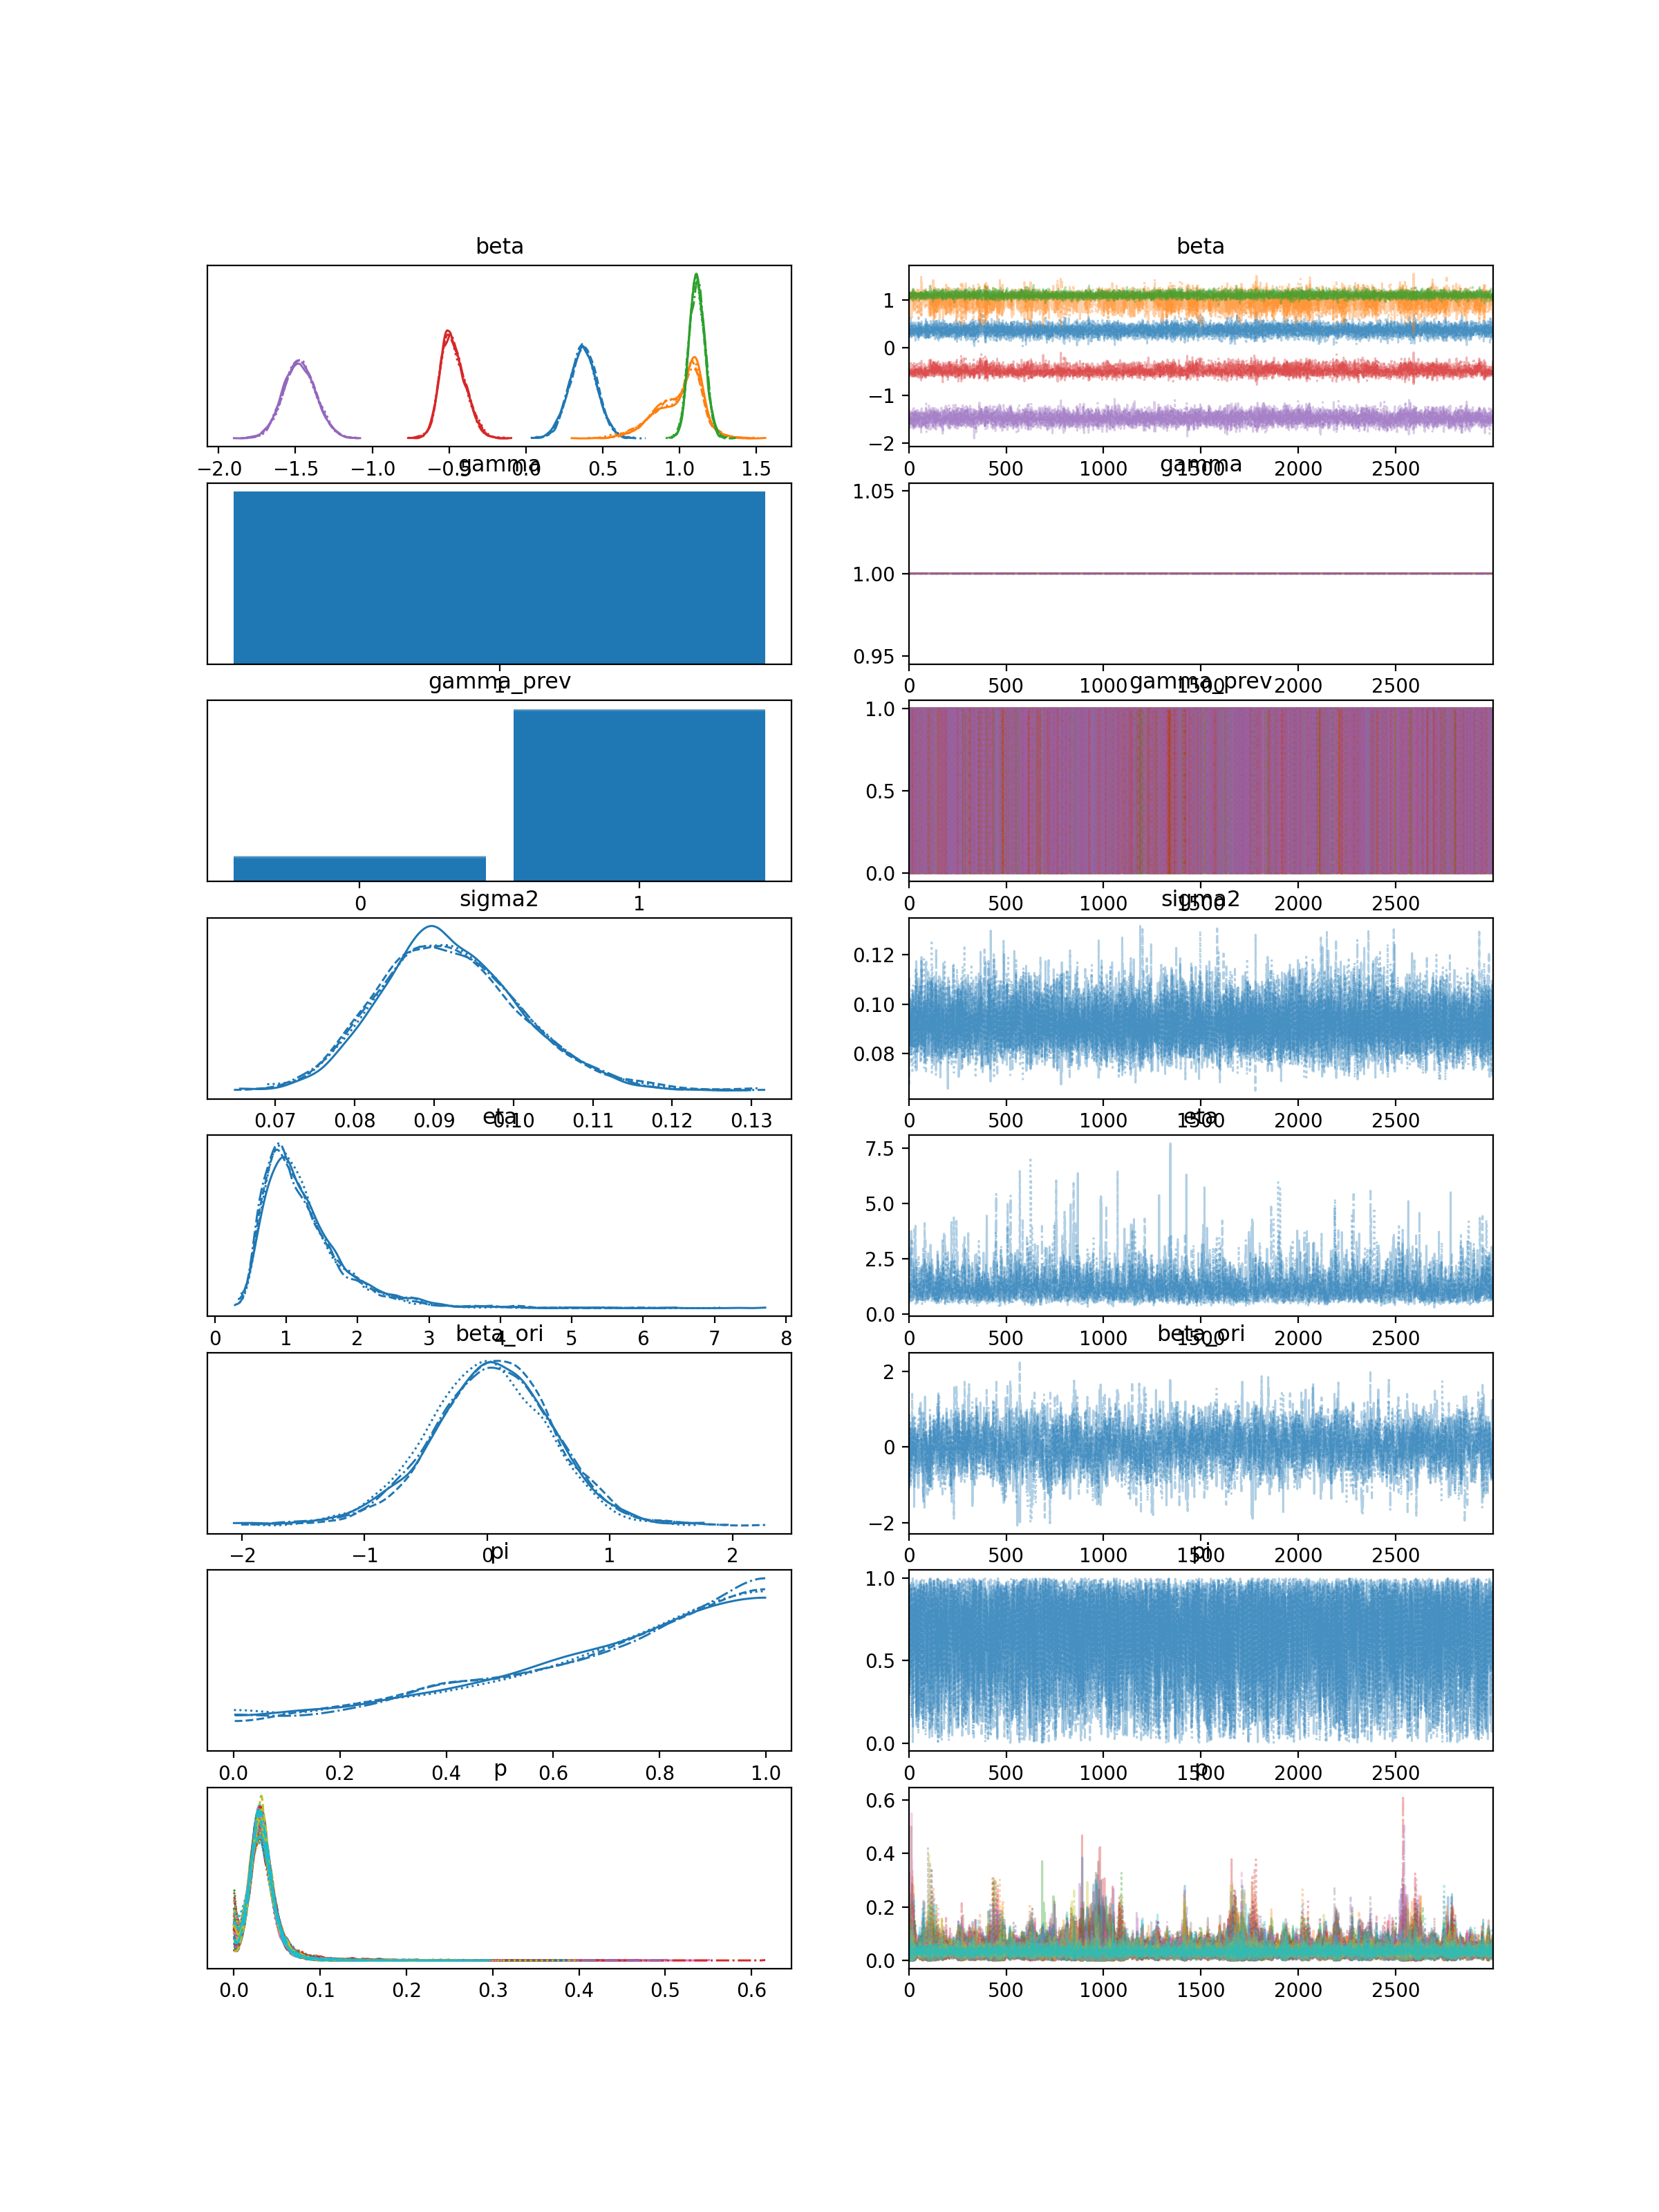

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        0.373  0.091   0.201    0.543      0.001    0.001    6478.0   
beta[1]        1.001  0.148   0.687    1.228      0.005    0.003    1127.0   
beta[2]        1.114  0.051   1.019    1.208      0.001    0.000    5858.0   
beta[3]       -0.473  0.081  -0.613   -0.315      0.002    0.002    1563.0   
beta[4]       -1.473  0.105  -1.668   -1.273      0.002    0.001    3820.0   
gamma[0]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[1]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[2]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[3]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[4]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma_prev[0]  0.874  0.332   0.000    1.000      0.003    0.002    9948.0   
gamma_prev[1]  0.882  0.322   0.000    1.000      0.003    0.002

In [66]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 5  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=2)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


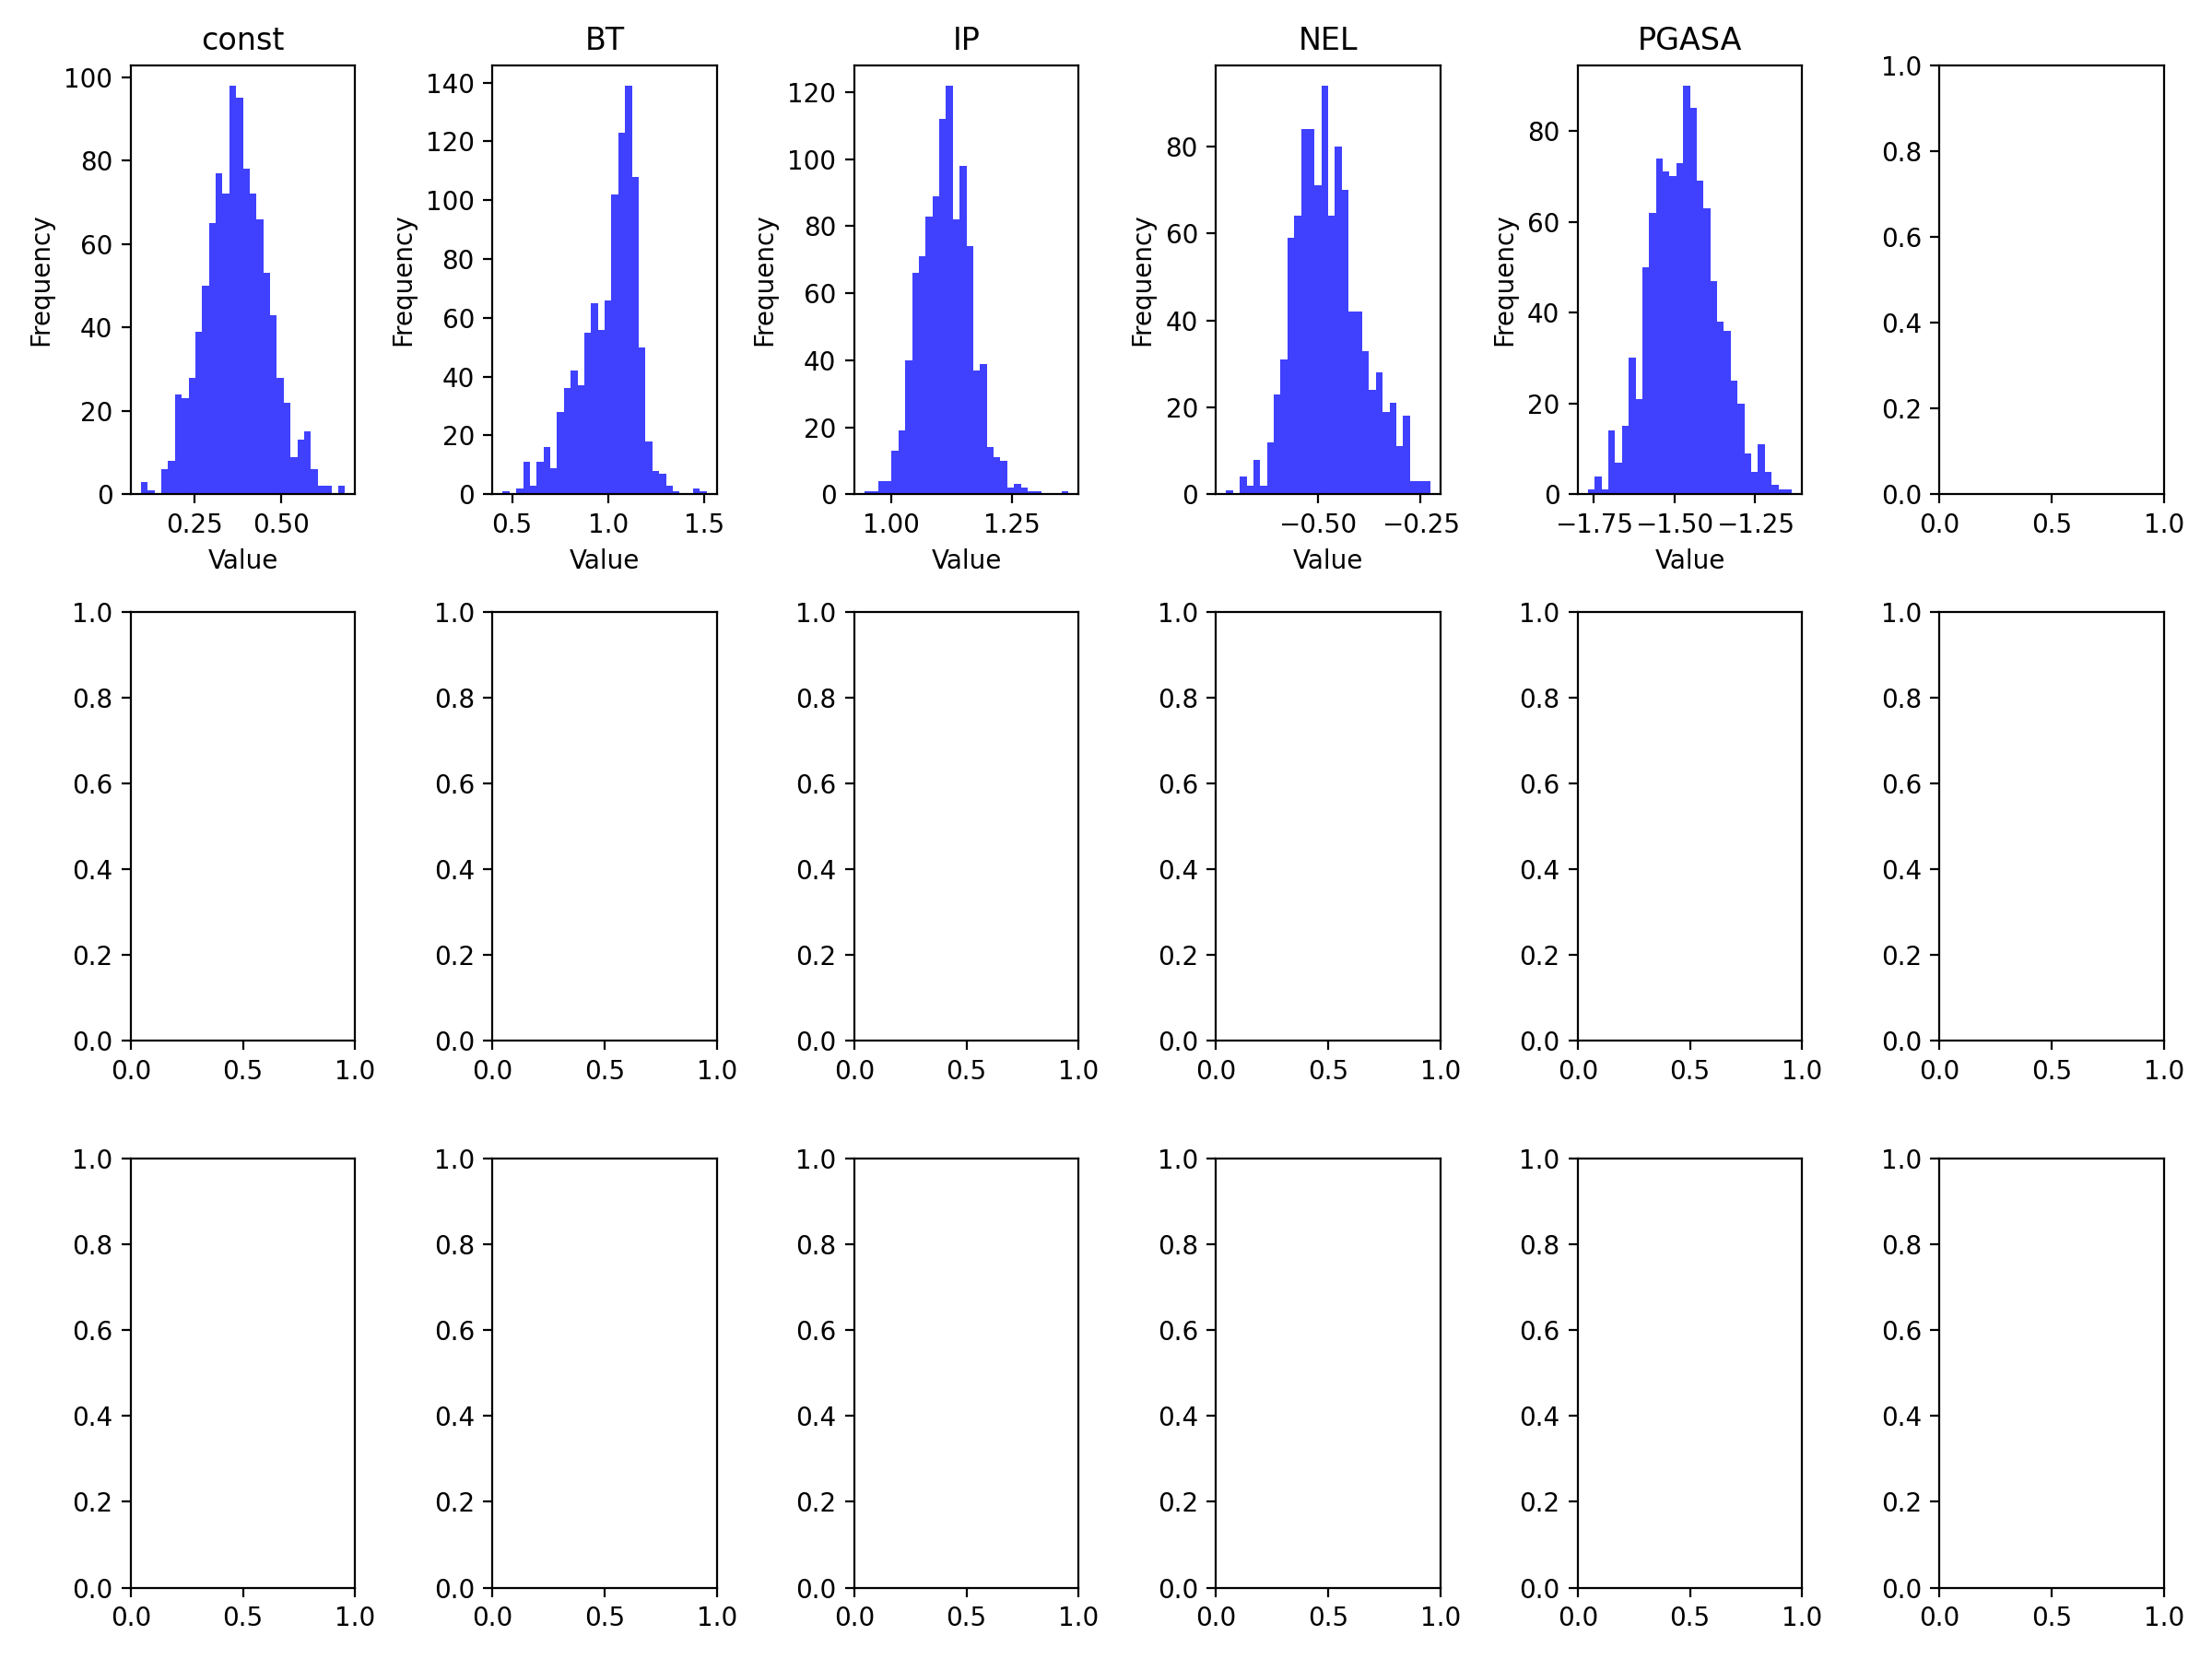

[1. 1. 1. 1. 1.]
[ 0.3722585   1.00281188  1.11365355 -0.47340819 -1.472465  ]
[15.172 13.873 13.253 14.762 16.207]
1000 samples' R² values=: 0.8616


In [70]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(12, 9))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

<IPython.core.display.Javascript object>


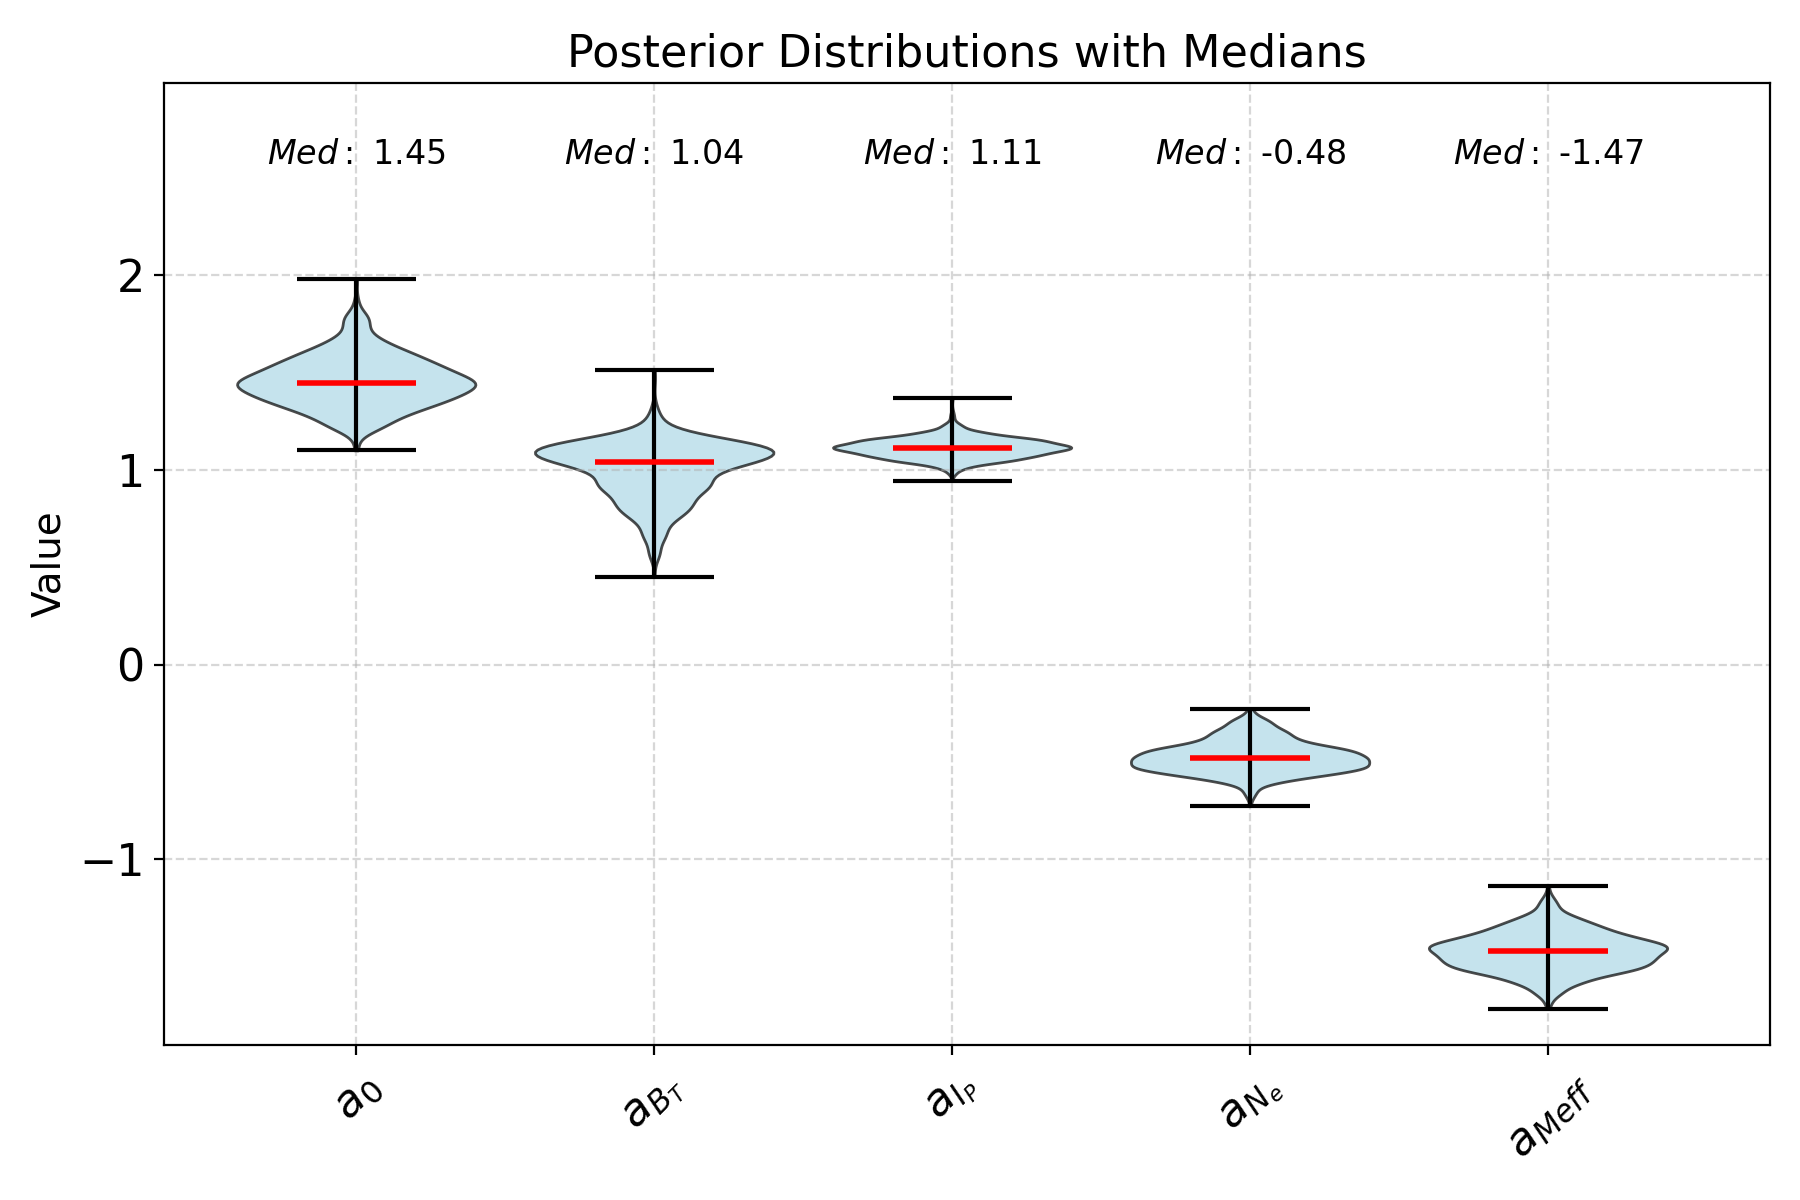


Gamma means: [1. 1. 1. 1. 1.]
S means: [ 0.3722585   1.00281188  1.11365355 -0.47340819 -1.472465  ]
Beta new look means: [15.172 13.873 13.253 14.762 16.207]

Predictions shape: (207,)
1000 samples' RMSE: 0.2318


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{B_T}$","$a_{I_P}$","$a_{N_e}$","$a_{Meff}$", "$D_{VERTPLT}$"]

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 6  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 or i in [5,6,7,8,9,10,11,12,13,14,15]:  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)


# 创建图形
plt.figure(figsize=(9,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 5  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if gamma_prob_0[i] > 0.1:  # 只显示非零概率
        prob_text = f"$P:$ {gamma_prob_0[i]:.1f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')
# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[0:], medians[0:]):
    plt.text(pos, y_top * 1.17, f"$Med:$ {median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
#plt.savefig('all_low_final_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")

<IPython.core.display.Javascript object>


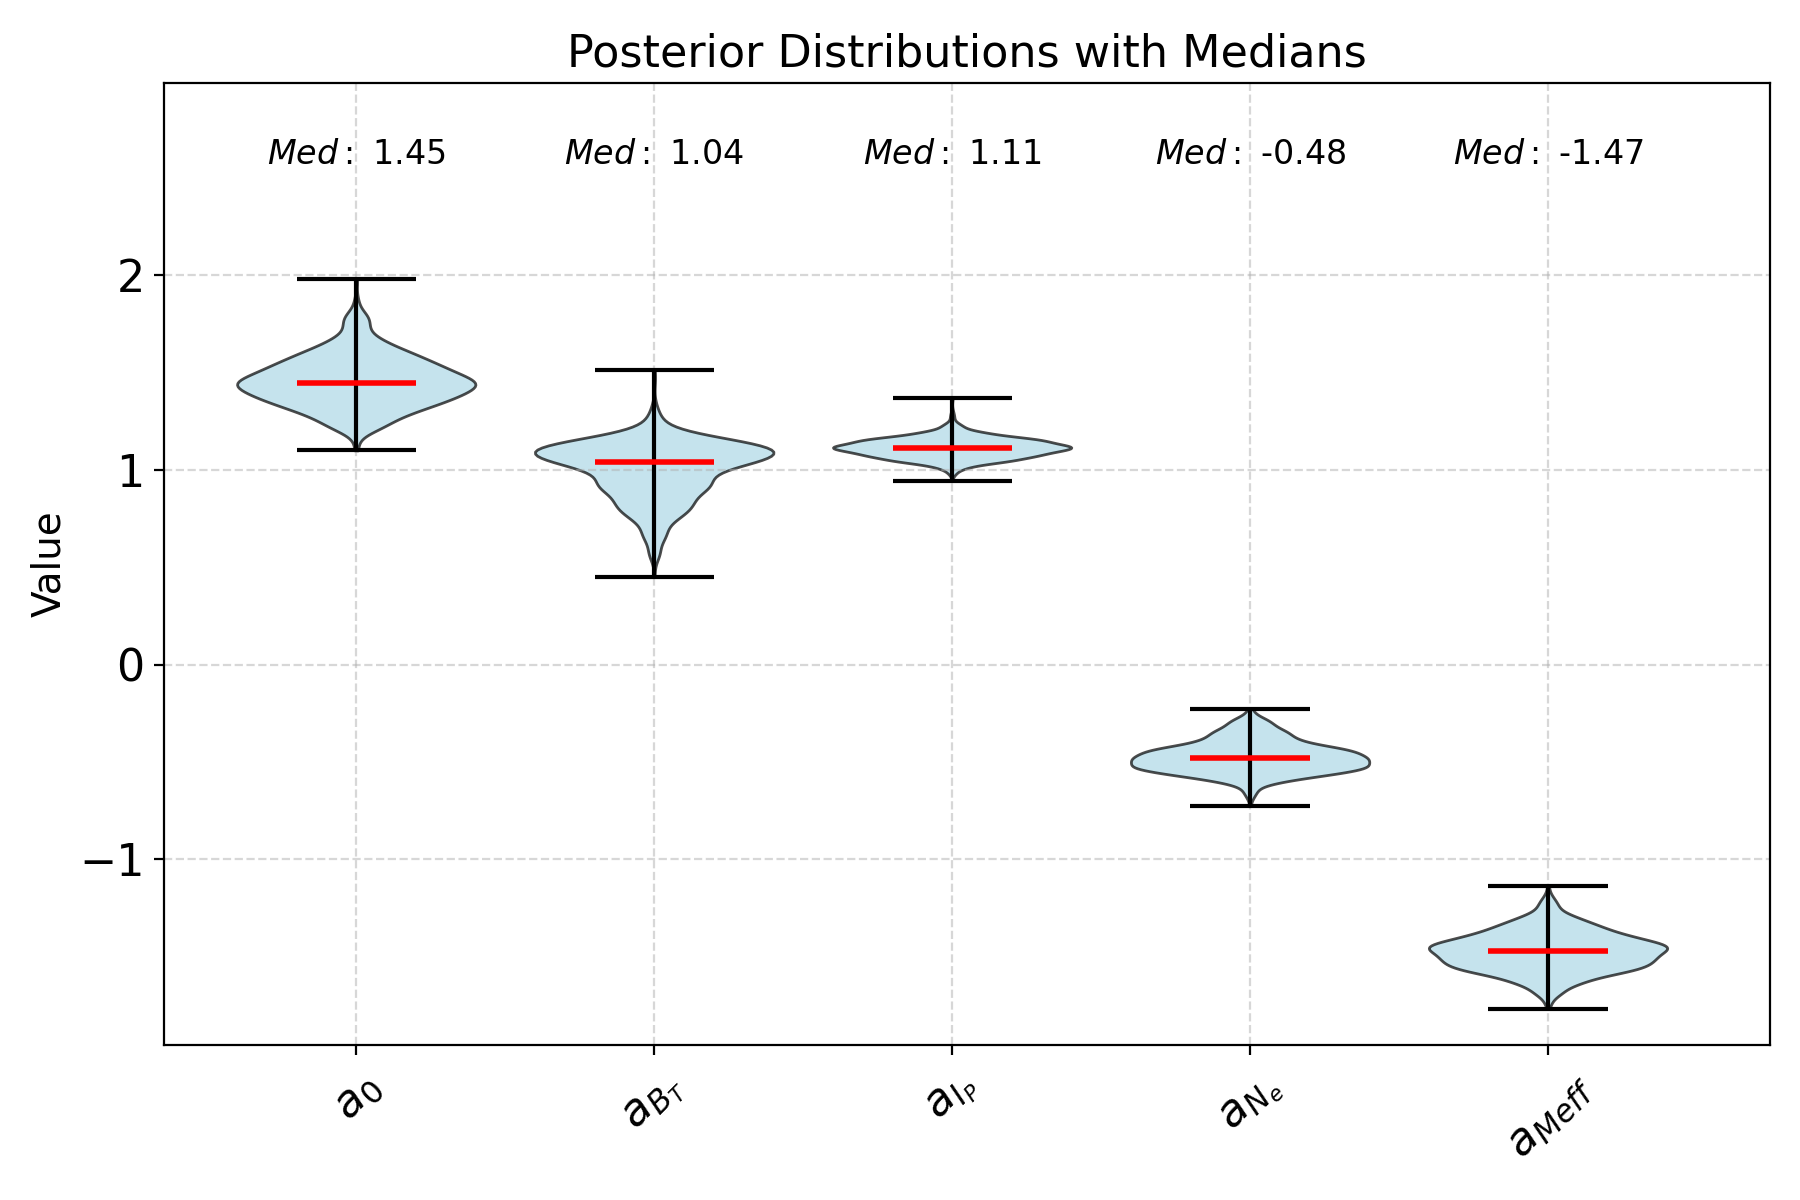


Gamma means: [1. 1. 1. 1. 1.]
S means: [ 0.3722585   1.00281188  1.11365355 -0.47340819 -1.472465  ]
Beta new look means: [15.172 13.873 13.253 14.762 16.207]

Predictions shape: (207,)
1000 samples' RMSE: 0.2318


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{B_T}$","$a_{I_P}$","$a_{N_e}$","$a_{Meff}$"]

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 5  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 or i in [5,6,7,8,9,10,11,12,13,14,15]:  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)


# 创建图形
plt.figure(figsize=(9,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 5  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if gamma_prob_0[i] > 0.1:  # 只显示非零概率
        prob_text = f"$P:$ {gamma_prob_0[i]:.1f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')
# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[0:], medians[0:]):
    plt.text(pos, y_top * 1.17, f"$Med:$ {median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
plt.savefig('noD_low_final_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")